## Setup: authenticate with Kaggle (token stored in Colab Secrets)

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [2]:
!pip install -q kaggle

## Download and unzip the competition dataset

In [3]:
!kaggle competitions download -c tensorflow-great-barrier-reef -p /content/data
!unzip -q /content/data/tensorflow-great-barrier-reef.zip -d /content/data

100% 14.2G/14.2G [13:16<00:00, 19.1MB/s]



## Load train.csv and parse the annotations column

In [4]:
import ast
import numpy as np
import pandas as pd

df = pd.read_csv('/content/data/train.csv')

# annotations is stored as a string in the CSV - parse it into real list-of-dict objects
df['annotations'] = df['annotations'].apply(ast.literal_eval)
df['num_boxes'] = df['annotations'].apply(len)
print(df.shape)
df.head()

(23501, 7)


,video_id,sequence,video_frame,sequence_frame,image_id,annotations,num_boxes
0,0,40258,0,0,0-0,[],0
1,0,40258,1,1,0-1,[],0
2,0,40258,2,2,0-2,[],0
3,0,40258,3,3,0-3,[],0
4,0,40258,4,4,0-4,[],0


## Data quality checks: types, nulls, duplicates, summary stats

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23501 entries, 0 to 23500
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        23501 non-null  int64 
 1   sequence        23501 non-null  int64 
 2   video_frame     23501 non-null  int64 
 3   sequence_frame  23501 non-null  int64 
 4   image_id        23501 non-null  object
 5   annotations     23501 non-null  object
 6   num_boxes       23501 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.3+ MB


In [6]:
df.describe()

,video_id,sequence,video_frame,sequence_frame,num_boxes
count,23501.000000,23501.000000,23501.000000,23501.000000,23501.000000
mean,1.078848,33181.644994,5727.471257,974.231224,0.506276
std,0.802202,18804.050915,3528.411913,795.594611,1.637906
min,0.000000,996.000000,0.000000,0.000000,0.000000
25%,0.000000,15827.000000,2349.000000,336.000000,0.000000
50%,1.000000,29859.000000,5553.000000,740.000000,0.000000
75%,2.000000,45518.000000,9048.000000,1447.000000,0.000000
max,2.000000,60754.000000,12347.000000,2987.000000,18.000000


In [7]:
# Only check image_id for duplicates - 'annotations' contains lists, which aren't hashable/comparable
print('Duplicate rows:', df.duplicated(subset=['image_id']).sum())

Duplicate rows: 0


## Basic image / video / sequence counts

In [8]:
print('Total frames:', len(df))
print('Total videos:', df['video_id'].nunique())
print('\nFrames per video:')
print(df['video_id'].value_counts())

# 'sequence' groups frames into continuous clips within a video - relevant for how we split train/val later
print('\nSequence per video:')
print(df.groupby('video_id')['sequence'].nunique())

Total frames: 23501
Total videos: 3

Frames per video:
video_id
2    8561
1    8232
0    6708
Name: count, dtype: int64

Sequence per video:
video_id
0    8
1    8
2    4
Name: sequence, dtype: int64


## Check image dimensions (are all frames the same size?)

In [9]:
from PIL import Image

# Sample-check resolution rather than opening all 23K images
sample_paths = df.sample(20, random_state=42).apply(
    lambda r: f'/content/data/train_images/video_{r["video_id"]}/{r["video_frame"]}.jpg', axis=1
)
dims = [Image.open(p).size for p in sample_paths if os.path.exists(p)]
print('Unique dimensions found in sample:', set(dims))

Unique dimensions found in sample: {(1280, 720)}


## Check for missing image files

In [11]:
# Confirm every row's image actually exists on disk (sanity check after a 14GB download)
all_paths = df.apply(
    lambda r: f'/content/data/train_images/video_{r["video_id"]}/{r["video_frame"]}.jpg', axis=1
)
missing = [p for p in all_paths if not os.path.exists(p)]
print(f'Missing image files: {len(missing)} out of {len(df)}')

Missing image files: 0 out of 23501


## Bounding box count distribution (the key class-imbalance finding)

Frames with zero starfish: 79.1%


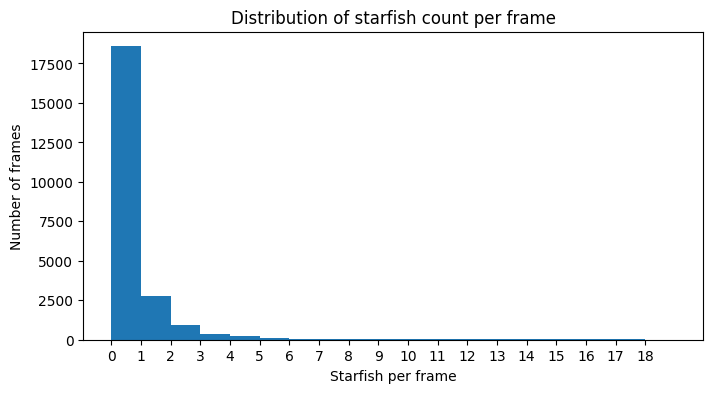

In [12]:
import matplotlib.pyplot as plt

# Most frames contain no starfish at all - this is the core class imbalance in this dataset
empty_frac = (df['num_boxes'] == 0).mean()
print(f'Frames with zero starfish: {empty_frac:.1%}')

plt.figure(figsize=(8, 4))
plt.hist(df['num_boxes'], bins=range(0, df['num_boxes'].max() + 2))
plt.xticks(range(0, df['num_boxes'].max() + 1))
plt.xlabel('Starfish per frame')
plt.ylabel('Number of frames')
plt.title('Distribution of starfish count per frame')
plt.show()

## Conclusions

**Class imbalance:** 79.1% of all frames (18,594 of 23,501) contain no
  starfish annotations. This will need to be accounted for in both the
  train/val split (to avoid an unrepresentative validation set) and later
  in model training (e.g. loss weighting, sampling strategy).

## Per-video imbalance breakdown

          total_frames  empty_frames  total_starfish  empty_pct
video_id                                                       
0                 6708          4565            3065   0.680531
1                 8232          6133            6384   0.745019
2                 8561          7884            2449   0.920920


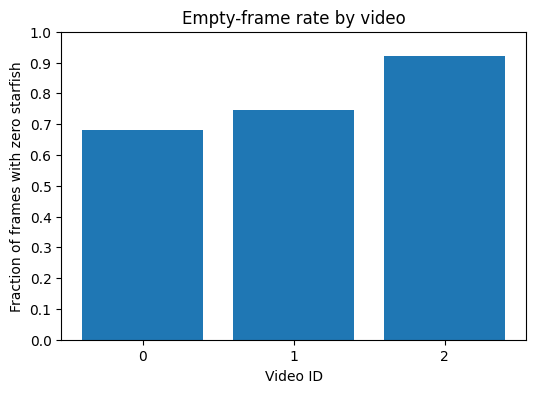

In [13]:
# Check whether the empty-frame imbalance is spread evenly across videos or concentrated in one -
# matters for how we split train/val later (GroupKFold by video)
video_stats = df.groupby('video_id').agg(
    total_frames=('num_boxes', 'count'),
    empty_frames=('num_boxes', lambda x: (x == 0).sum()),
    total_starfish=('num_boxes', 'sum')
)
video_stats['empty_pct'] = (video_stats['empty_frames'] / video_stats['total_frames'])
print(video_stats)

plt.figure(figsize=(6, 4))
plt.bar(video_stats.index.astype(str), video_stats['empty_pct'])
plt.yticks([i / 10 for i in range(0, 11)])
plt.xlabel('Video ID')
plt.ylabel('Fraction of frames with zero starfish')
plt.title('Empty-frame rate by video')
plt.show()

# Conclusions
Video 2 is disproportionately empty, and has notably fewer sequences (4
vs. 8) than the other two — this makes it the hardest video to represent fairly in any split.

**Implication for train/val splitting:** because the videos differ this
  much, a naive "hold out one whole video" split would produce a validation
  set that's either far too easy (mostly empty, if video 2 is held out) or
  unrepresentative in the opposite direction. Frames within a video are also
  highly correlated (near-duplicate adjacent frames), so splitting must
  respect video/sequence boundaries to avoid data leakage. Together, these
  findings motivate a **sequence-level, per-video split** rather than a
  simple random or whole-video split — implemented in
  `notebooks/train_val_split.ipynb`.
  

## Total starfish per video

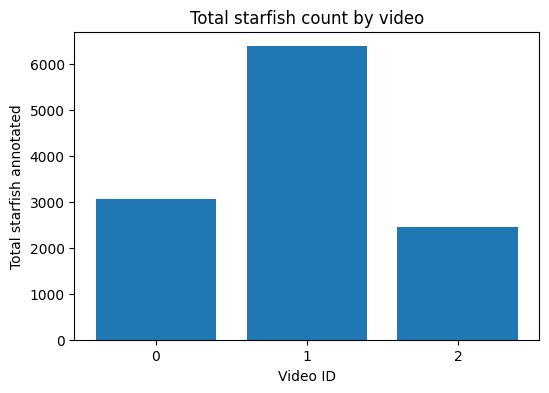

In [15]:
plt.figure(figsize=(6, 4))
plt.bar(video_stats.index.astype(str), video_stats['total_starfish'])
plt.xlabel('Video ID')
plt.ylabel('Total starfish annotated')
plt.title('Total starfish count by video')
plt.show()

## Bounding box size distribution (how tiny are the starfish?)

                  x             y         width        height      area_pct
count  11898.000000  11898.000000  11898.000000  11898.000000  11898.000000
mean     490.038578    346.267944     47.885443     42.723231      0.245189
std      274.052305    185.139016     17.448619     15.379084      0.214086
min        0.000000      0.000000     17.000000     13.000000      0.031250
25%      278.000000    198.000000     35.000000     32.000000      0.125326
50%      477.000000    346.000000     45.000000     40.000000      0.193793
75%      664.000000    493.750000     57.000000     52.000000      0.315430
max     1244.000000    706.000000    243.000000    222.000000      5.660807


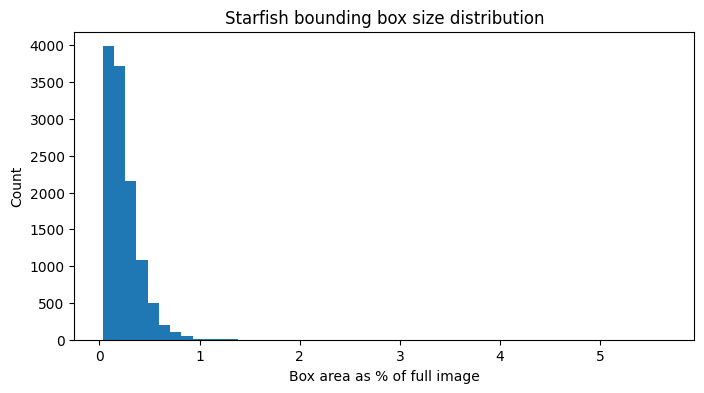

In [16]:
all_boxes = [box for boxes in df['annotations'] for box in boxes]
box_df = pd.DataFrame(all_boxes)
box_df['area'] = box_df['width'] * box_df['height']
box_df['area_pct'] = box_df['area'] / (1280 * 720) * 100

print(box_df[['x', 'y', 'width', 'height', 'area_pct']].describe())

plt.figure(figsize=(8, 4))
plt.hist(box_df['area_pct'], bins=50)
plt.xlabel('Box area as % of full image')
plt.ylabel('Count')
plt.title('Starfish bounding box size distribution')
plt.show()

## Bounding box outlier / sanity checks

In [17]:
# Sanity-check annotation quality: invalid sizes, boxes extending past the frame, and odd shapes
invalid_size = box_df[(box_df['width'] <= 0) | (box_df['height'] <= 0)]
print(f'Boxes with invalid width/height: {len(invalid_size)}')

Img_width, Img_height = 1280, 720
out_of_bounds = box_df[
    (box_df['x'] < 0) |
    (box_df['y'] < 0) |
    (box_df['x'] + box_df['width'] > Img_width) |
    (box_df['y'] + box_df['height'] > Img_height)
]
print(f'Boxes extending outside image bounds: {len(out_of_bounds)}')

box_df['aspect_ratio'] = box_df['width'] / box_df['height']
print()
print(box_df['aspect_ratio'].describe())
weird_shape = box_df[(box_df['aspect_ratio'] > 3) | (box_df['aspect_ratio'] < 1/3)]
print(f'\nUnusually elongated boxes: {len(weird_shape)}')

Boxes with invalid width/height: 0
Boxes extending outside image bounds: 20

count    11898.000000
mean         1.149492
std          0.278066
min          0.247788
25%          0.985294
50%          1.108108
75%          1.258065
max          4.625000
Name: aspect_ratio, dtype: float64

Unusually elongated boxes: 19


## How far outside the image do the out-of-bounds boxes actually go?

In [18]:
# Small overflow suggests annotator imprecision at the frame edge rather than corrupted data
overflow_x = (box_df['x'] + box_df['width'] - Img_width).clip(lower=0)
overflow_y = (box_df['y'] + box_df['height'] - Img_height).clip(lower=0)
negative_x = (-box_df['x']).clip(lower=0)
negative_y = (-box_df['y']).clip(lower=0)

max_overflow = pd.concat([overflow_x, overflow_y, negative_x, negative_y], axis=1).max(axis=1)
print(max_overflow[max_overflow > 0].describe())

count    20.000000
mean      6.700000
std       6.906138
min       1.000000
25%       1.000000
50%       4.000000
75%       9.750000
max      22.000000
dtype: float64


## Visualize sample frames with boxes drawn on them

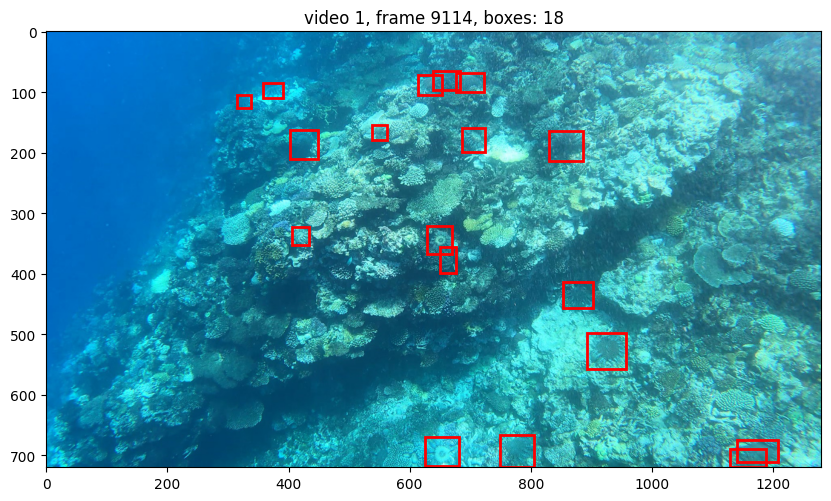

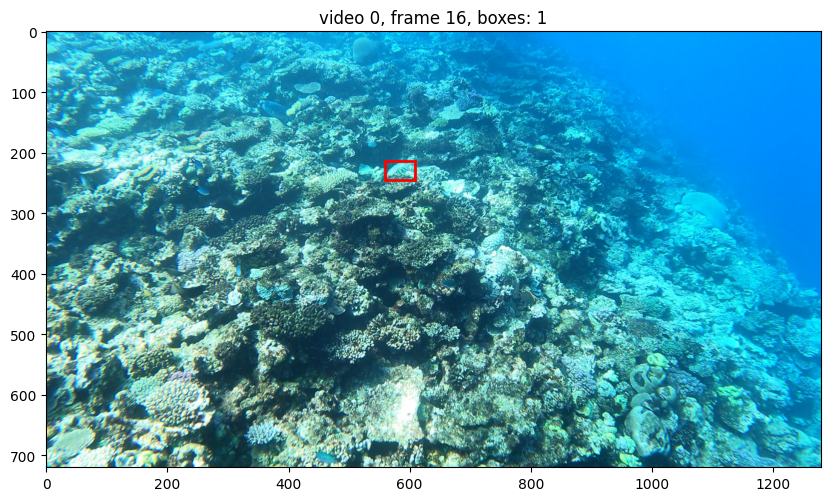

In [19]:
import matplotlib.patches as patches

def show_frame(row):
    path = f'/content/data/train_images/video_{row["video_id"]}/{row["video_frame"]}.jpg'
    img = Image.open(path)
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)
    for box in row['annotations']:
        rect = patches.Rectangle(
            (box['x'], box['y']), box['width'], box['height'],
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
    ax.set_title(f'video {row["video_id"]}, frame {row["video_frame"]}, boxes: {row["num_boxes"]}')
    plt.show()

# Visualize a dense example and a sparse example to make the tiny-object detection challenge concrete
show_frame(df.loc[df['num_boxes'].idxmax()])
show_frame(df[df['num_boxes'].between(1, 3)].iloc[0])